# CatBoost with Chi squared statistic filtering (Original columns)

In this notebook a hybrid focus will be used:
1. **Statistical filtering**: Chi Squared is used to identify which categorical variables have significant categories
2. **Non-encoded columns**: Instead of using One-Hot Encoding, the full original columns are included
3. **native Catboost**: CatBoost is handed the original categorical columns


In [ ]:
import pandas as pd
import os
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cargar el dataset
filename = '251111_hospital.csv'
possible_paths = [filename, os.path.join('Exam_2025', filename)]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if file_path:

    df = pd.read_csv(file_path, sep='|')
    print(f"Dataset dimensions: {df.shape}")

    # Eliminar duplicados
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"There were {duplicates} duped rows")
        df = df.drop_duplicates()
        print(f"Final dimensiosn: {df.shape}")

    display(df.head())
else:
    print(f"Error. no file: {filename}.")

Cargando archivo desde: 251111_hospital.csv
Dimensiones del dataset: (4772, 22)
Se encontraron 2 filas duplicadas. Eliminándolas...
Dimensiones después de eliminar duplicados: (4770, 22)


,periodo,periodo_estudio,paridad,edad_madre,nacionalidad,estado_civil_madre,lugar_control_comuna,embarazo_controlado,embarazo_gemelar,lugar_parto,...,condicion_rn,sexo_rn,peso_nacimiento,edad_gestacional,antropometria,apgar_1min,apgar_5min,hospitalizado,lm_inmediato,acompanante
0,10-2020,PANDEMICO,PRIMIPARA,33,CHILENA,CONVIVIENTE,COLTAUCO,CONTROLADO,NO,PARTO HOSP,...,NACIDO VIVO,MASCULINO,4085,41,AEG,3,7,NO,NO,NO
1,10-2020,PANDEMICO,MULTIPARA,22,CHILENA,SOLTERA,RANCAGUA,CONTROLADO,NO,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2660,37,AEG,6,8,NO,NO,NO
2,12-2020,PANDEMICO,MULTIPARA,37,CHILENA,CONVIVIENTE,RENGO,CONTROLADO,SI,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2750,35,AEG,7,8,NO,NO,NO
3,11-2020,PANDEMICO,MULTIPARA,40,CHILENA,CONVIVIENTE,RENGO,CONTROLADO,SI,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2485,36,AEG,7,8,NO,NO,NO
4,02-2021,PANDEMICO,MULTIPARA,33,CHILENA,CASADA,RANCAGUA,CONTROLADO,SI,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2810,38,AEG,7,8,NO,NO,NO


In [ ]:
# Eliminar la columna 'periodo' (no aporta información predictiva)
if 'periodo' in df.columns:
    df = df.drop(columns=['periodo'])
    print("Columna 'periodo' eliminada.")

# Definir variable objetivo y características
target_col = 'periodo_estudio'
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode target varaible
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"Clases objetivo: {le_target.classes_}")

# Separar columnas numéricas y categóricas
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical variables ({len(cat_cols)}): {cat_cols}")
print(f"Numeric variables({len(num_cols)}): {num_cols}")

Columna 'periodo' eliminada.
Clases objetivo: ['PANDEMICO' 'PREPANDEMICO']

Variables Categóricas (15): ['paridad', 'nacionalidad', 'estado_civil_madre', 'lugar_control_comuna', 'embarazo_controlado', 'embarazo_gemelar', 'lugar_parto', 'tipo_parto', 'tipo_cesarea', 'condicion_rn', 'sexo_rn', 'antropometria', 'hospitalizado', 'lm_inmediato', 'acompanante']
Variables Numéricas (5): ['edad_madre', 'peso_nacimiento', 'edad_gestacional', 'apgar_1min', 'apgar_5min']


## Filtrado Estadístico

### Chi-Cuadrado para Variables Categóricas
Se aplicará la prueba Chi-Cuadrado para identificar qué columnas categóricas tienen al menos una categoría significativa.

In [ ]:

# We encode to apply chi squared
X_cat_encoded = pd.get_dummies(X[cat_cols])
chi2_selector = SelectKBest(chi2, k='all').fit(X_cat_encoded, y_encoded)

# Create results table
chi2_stats = pd.DataFrame({
    'Feature': X_cat_encoded.columns,
    'Chi2': chi2_selector.scores_,
    'P_Value': chi2_selector.pvalues_
}).sort_values('Chi2', ascending=False)

print("Top 15 Chi squared features:")
display(chi2_stats.head(15))

# Filtrar características significativas (p < 0.05)
significant_cat_features = chi2_stats[chi2_stats['P_Value'] < 0.05]['Feature'].tolist()
print(f"\nSignificant categorical features (p < 0.05): {len(significant_cat_features)}")

Top 15 Chi-Cuadrado Features:


,Feature,Chi2,P_Value
110,lm_inmediato_NO DESCRITO,171.063057,4.334992e-39
52,lugar_control_comuna_MOSTAZAL,157.587494,3.808695e-36
88,tipo_cesarea_ELECTIVA,136.840826,1.306492e-31
40,lugar_control_comuna_EXTRASISTEMA,132.392818,1.227587e-30
112,acompanante_NO,90.099006,2.265355e-21
81,embarazo_controlado_SIN CONTROL,63.136087,1.929072e-15
108,lm_inmediato_NO,49.164592,2.353610e-12
91,tipo_cesarea_URGENCIA,38.310599,6.033406e-10
107,hospitalizado_SI,24.615072,7.000208e-07
90,tipo_cesarea_NO DESCRITO,21.197685,4.142645e-06



Total de features categóricas significativas (p < 0.05): 25


In [ ]:
# KEY: Extract original columns from significant features

original_cat_columns = set()

for feature in significant_cat_features:

    for col in cat_cols:
        if feature.startswith(col + '_'):
            original_cat_columns.add(col)
            break

original_cat_columns = sorted(list(original_cat_columns))
print(f"Categorical columns to include ({len(original_cat_columns)}):")
for col in original_cat_columns:
    print(f"  - {col}")

Columnas categóricas originales a incluir (10):
  - acompanante
  - embarazo_controlado
  - estado_civil_madre
  - hospitalizado
  - lm_inmediato
  - lugar_control_comuna
  - nacionalidad
  - paridad
  - tipo_cesarea
  - tipo_parto


### ANOVA para Variables Numéricas
Se aplicará ANOVA F-test para identificar variables numéricas significativas.

In [ ]:
# Apply ANOVA to numeric variables
f_selector = SelectKBest(f_classif, k='all').fit(X[num_cols], y_encoded)

# Create results table
anova_stats = pd.DataFrame({
    'Feature': num_cols,
    'F_Score': f_selector.scores_,
    'P_Value': f_selector.pvalues_
}).sort_values('F_Score', ascending=False)

print("ANOVA Results:")
display(anova_stats)

# Filtrar características significativas (p < 0.05)
significant_num_features = anova_stats[anova_stats['P_Value'] < 0.05]['Feature'].tolist()
print(f"\nSignificant numeric variables (p < 0.05): {significant_num_features}")

Resultados ANOVA:


,Feature,F_Score,P_Value
4,apgar_5min,14.167387,0.000169
3,apgar_1min,10.052890,0.001531
0,edad_madre,9.609430,0.001947
1,peso_nacimiento,4.133195,0.042105
2,edad_gestacional,3.625068,0.056975



Variables numéricas significativas (p < 0.05): ['apgar_5min', 'apgar_1min', 'edad_madre', 'peso_nacimiento']


## Final dataset construction

- **Original categorical variables** (without encoding) that have at least one significant category
- **Numeric variables** Significant according to ANOVA

In [ ]:
# Build the dataset with the original columns
final_features = original_cat_columns + significant_num_features

X_final = X[final_features].copy()

print(f"Final dataset dimensions: {X_final.shape}")
print(f"\nFinal dataset columns:")
print(f"  Categorical ({len(original_cat_columns)}): {original_cat_columns}")
print(f"  Numeric ({len(significant_num_features)}): {significant_num_features}")

display(X_final.head())

Dimensiones del dataset final: (4770, 14)

Columnas en el dataset final:
  Categóricas (10): ['acompanante', 'embarazo_controlado', 'estado_civil_madre', 'hospitalizado', 'lm_inmediato', 'lugar_control_comuna', 'nacionalidad', 'paridad', 'tipo_cesarea', 'tipo_parto']
  Numéricas (4): ['apgar_5min', 'apgar_1min', 'edad_madre', 'peso_nacimiento']


,acompanante,embarazo_controlado,estado_civil_madre,hospitalizado,lm_inmediato,lugar_control_comuna,nacionalidad,paridad,tipo_cesarea,tipo_parto,apgar_5min,apgar_1min,edad_madre,peso_nacimiento
0,NO,CONTROLADO,CONVIVIENTE,NO,NO,COLTAUCO,CHILENA,PRIMIPARA,URGENCIA,CESAREA,7,3,33,4085
1,NO,CONTROLADO,SOLTERA,NO,NO,RANCAGUA,CHILENA,MULTIPARA,URGENCIA,CESAREA,8,6,22,2660
2,NO,CONTROLADO,CONVIVIENTE,NO,NO,RENGO,CHILENA,MULTIPARA,URGENCIA,CESAREA,8,7,37,2750
3,NO,CONTROLADO,CONVIVIENTE,NO,NO,RENGO,CHILENA,MULTIPARA,ELECTIVA,CESAREA,8,7,40,2485
4,NO,CONTROLADO,CASADA,NO,NO,RANCAGUA,CHILENA,MULTIPARA,ELECTIVA,CESAREA,8,7,33,2810


In [ ]:
# Split data (85% train, 15% test, random_state=314)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_encoded, test_size=0.15, random_state=314
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (4054, 14)
Test set shape: (716, 14)


## Entrenamiento del Modelo CatBoost

CatBoost recibirá las columnas categóricas **sin codificar** y las manejará internamente.

In [ ]:
# Specify categorical columns for catboost
cat_features_indices = [i for i, col in enumerate(final_features) if col in original_cat_columns]

print(f"Categorical features index for catboost {cat_features_indices}")
print(f"Categorical columns: {[final_features[i] for i in cat_features_indices]}")

# Entrenar modelo CatBoost
model = CatBoostClassifier(
    random_state=314,
    verbose=100,
    cat_features=cat_features_indices,
    learning_rate=0.05,
)
model.fit(X_train, y_train)
print("\nSuccesfully trained model.")

Índices de features categóricas para CatBoost: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Columnas categóricas: ['acompanante', 'embarazo_controlado', 'estado_civil_madre', 'hospitalizado', 'lm_inmediato', 'lugar_control_comuna', 'nacionalidad', 'paridad', 'tipo_cesarea', 'tipo_parto']
0:	learn: 0.6806211	total: 76.6ms	remaining: 1m 16s
100:	learn: 0.5153688	total: 7.44s	remaining: 1m 6s
200:	learn: 0.4862370	total: 14.7s	remaining: 58.5s
300:	learn: 0.4579784	total: 22.2s	remaining: 51.5s
400:	learn: 0.4343285	total: 29.7s	remaining: 44.3s
500:	learn: 0.4139248	total: 37.2s	remaining: 37.1s
600:	learn: 0.3961283	total: 44.7s	remaining: 29.7s
700:	learn: 0.3772838	total: 52.3s	remaining: 22.3s
800:	learn: 0.3616251	total: 59.8s	remaining: 14.9s
900:	learn: 0.3473675	total: 1m 7s	remaining: 7.41s
999:	learn: 0.3335925	total: 1m 14s	remaining: 0us

Modelo entrenado exitosamente.


## Evaluación del Modelo

In [ ]:
# Evaluate model
y_pred = model.predict(X_test)

# Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.7402234636871509
Precision: 0.761168384879725
Recall: 0.9040816326530612
F1 Score: 0.8264925373134329


In [ ]:
# Evaluation matrix
s = (0.6*accuracy + 0.4*f1)**(1.3)
print(s)

0.7176228888421953


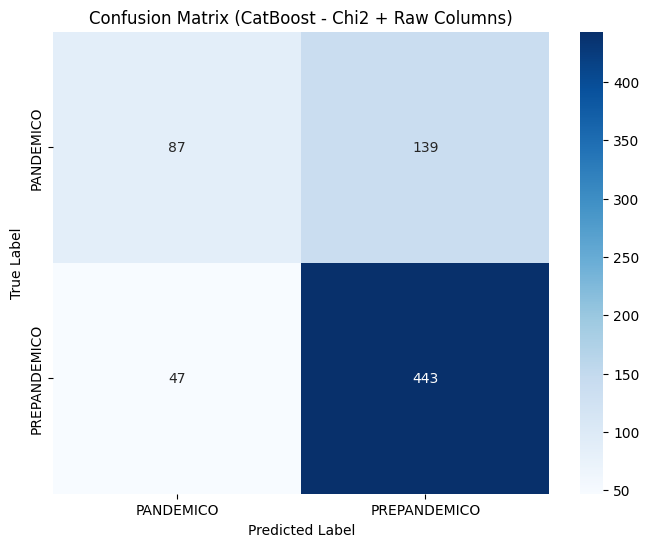

In [ ]:
# Confusion matrix visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix (CatBoost - Chi2 + Raw Columns)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [11]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': final_features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 14 most important features:")
display(feature_importance.head(14))

# Visualización
plt.figure(figsize=(10, 6))
top_n = 14
top_features = feature_importance.head(top_n)
plt.barh(range(top_n), top_features['Importance'])
plt.yticks(range(top_n), top_features['Feature'])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importance (CatBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

NameError: name 'final_features' is not defined

##Focus Summary

This notebook implements a hybrid approach

1. Statistical filtering: Chi-Square and ANOVA tests are used to identify relevant features

2. Original columns: Instead of using dummy variables, the full original categorical columns are extracted

3. Native CatBoost: The model receives the categorical columns without encoding

Advantages:

1. Reduces dimensionality through statistical filtering

2. Leverages CatBoost's native ability to handle categoricals

3. Avoids the column explosion from One-Hot Encoding

4. Maintains the interpretability of the original variables